# Teleportation in simyuj

This notebook rebuilds the NetSquid teleportation example in the same architectural style as the BB84 example: a `Network` with nodes, node-local devices, node agents, runtime wires, and a `SessionRuntime` that starts the agents.

## Model Plan

The scenario follows the NetSquid example at the level of physics and timing while using simyuj components:

- The network has three nodes: `alice`, `bob`, and `charlie`.
- Charlie owns the entangled-pair source and a Charlie agent starts it.
- Alice owns two one-position quantum memories: one for the input state and one for her half of Charlie's entangled pair.
- Alice also owns a `BellStateAnalyzer`; her agent emits both stored qubits into that device instead of calling a direct qstate Bell measurement.
- Bob owns a quantum memory and a Bob agent waits for Charlie's qubit plus Alice's classical message, applies the Pauli correction, and records fidelity.
- Runtime links and wires are declared on the `Network`, and agents receive memory/source/BSA reports through `AGENT_REPORT` ports.

The Bell measurement is therefore a real detector-device event in the simyuj network. The remaining qstate work is owned by components: memories prepare/store/emit qubits, the BSA performs Bell analysis, and Bob's memory applies the correction.


In [12]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-simyuj")
from matplotlib import pyplot as plt
from IPython.display import display

from simyuj.components.channels import (
    ACTION_TRANSMIT_CLASSICAL,
    ACTION_TRANSMIT_QUANTUM,
    ClassicalChannel,
    QuantumChannel,
)
from simyuj.components.detectors import (
    ACTION_RUN_BELL_ANALYSIS,
    BellStateAnalyzer,
    DetectionReport,
)
from simyuj.components.memories import (
    MEMORY_ABSORB,
    MemoryAbsorbReport,
    MemoryDiscardReport,
    MemoryEmitReport,
    MemoryOperatorReport,
    QuantumMemory,
)
from simyuj.components.sources import EntangledPairSource, SourcePreparationReport
from simyuj.control import AGENT_MESSAGE, AGENT_REPORT, NodeAgent, SessionRuntime
from simyuj.engine import Timeline
from simyuj.network import Network, Node
from simyuj.primitives.messages.transport import ClassicalMessage
from simyuj.primitives.subsystems import SubsystemHandle
from simyuj.primitives.units import seconds_to_ticks, ticks_to_seconds
from simyuj.qstate import BellResult, SubsystemId
from simyuj.qstate.noise import DepolarizingNoise
from simyuj.qstate.ops import H, I, S, X, Z, correction_for_bell, unitary
from simyuj.qstate.state import fidelity, plus_i, zero
from simyuj.signal import EncodingScheme, Signal, SignalKind


## Configuration

The default sweep uses the same distance, source-period formula, depolar-rate grid, and `1000` teleportation cycles per rate as the NetSquid example. Times are stored in simyuj ticks, where `1 tick = 1 ps`.

In [13]:
NS = 1_000

INIT_TICKS = 3 * NS
ONE_QUBIT_GATE_TICKS = 1 * NS
BELL_MEASUREMENT_TICKS = (4 + 1 + 7 + 7) * NS

DEFAULT_DISTANCE_KM = 4e-3
DEFAULT_DEPHASE_RATE = 0.0
OUTPUT_DIR = Path("zmy_tests/benchmarking")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path(".")
PLOT_PATH = OUTPUT_DIR / "teleportation_fidelity.png"
NUM_RUNS = 1000
MASTER_SEED = 42

DEPOLAR_RATES = [1e6 * i for i in range(0, 200, 10)]

ACTION_ALICE_START = "teleportation_alice_start"
ACTION_ALICE_MEMORY_REPORT = "teleportation_alice_memory_report"
ACTION_BOB_MEMORY_REPORT = "teleportation_bob_memory_report"
ACTION_BOB_CLASSICAL = "teleportation_bob_classical"

## Shared Helpers

In [14]:
def meta_get(meta: tuple[tuple[str, object], ...], key: str, default=None):
    value = default
    for item_key, item_value in meta:
        if item_key == key:
            value = item_value
    return value


def correction_operator(x_bit: int, z_bit: int):
    matrix = np.eye(2, dtype=np.complex128)
    names: list[str] = []
    if x_bit:
        matrix = X.matrix @ matrix
        names.append("X")
    if z_bit:
        matrix = Z.matrix @ matrix
        names.append("Z")
    if not names:
        return I
    if len(names) == 1:
        return X if names[0] == "X" else Z
    return unitary(matrix, name="".join(names))


def bsa_round_key(round_id: int) -> str:
    return f"teleport:{round_id}"


def convert_memory_targets_to_density(
    timeline: Timeline,
    memory_positions: tuple[tuple[QuantumMemory, int], ...],
) -> None:
    converted_refs: set[int] = set()
    for memory, position in memory_positions:
        subsystem = memory.positions[position].memory_subsystem
        if subsystem is None:
            continue
        state_ref = timeline.qstate.state_of(subsystem)
        if state_ref not in converted_refs:
            timeline.qstate.convert(state_ref, "density")
            converted_refs.add(state_ref)


## Collector And Node Agents

These are real control-plane agents. They are registered on nodes and receive runtime contexts from `SessionRuntime`, matching the BB84 example structure.

In [15]:
class TeleportationCollector:
    def __init__(self) -> None:
        self.rows: list[dict[str, object]] = []

    def record(self, **row: object) -> None:
        self.rows.append(dict(row))

    def dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.rows)


@dataclass(slots=True)
class CharlieEntanglementAgent(NodeAgent):
    source_device_name: str = "source"
    source_reports: list[SourcePreparationReport] = field(default_factory=list)
    trace: list[dict[str, object]] = field(default_factory=list)

    def on_start(self, start, ctx) -> None:
        del start
        source = ctx.devices.get(self.source_device_name)
        if not isinstance(source, EntangledPairSource):
            raise TypeError("Charlie source device must be EntangledPairSource")
        source.schedule_start(ctx.timeline)
        self.trace.append(
            {"time": ctx.timeline.current_time, "side": "charlie", "event": "source_started"}
        )

    def on_report(self, report: object, ctx) -> None:
        del ctx
        if isinstance(report, SourcePreparationReport):
            self.source_reports.append(report)
            return
        raise TypeError(f"Charlie received unsupported report: {type(report)!r}")


@dataclass(slots=True)
class AliceTeleportationAgent(NodeAgent):
    input_memory_name: str = "input_memory"
    entanglement_memory_name: str = "entanglement_memory"
    peer_id: str = "bob_agent"
    out_port: str = "to_bob"
    round_id: int = 0
    input_ready: bool = False
    entanglement_ready: bool = False
    bsm_in_flight: bool = False
    trace: list[dict[str, object]] = field(default_factory=list)

    def on_start(self, start, ctx) -> None:
        del start
        self._start_input_preparation(ctx)

    def on_timer(self, timer, ctx) -> None:
        action = meta_get(timer.meta, "teleport_action")
        if action == "input_h":
            round_id = int(timer.correlation_id)
            ctx.memory.apply(
                self.input_memory_name,
                (0,),
                H,
                request_id=f"{self.agent_id}:input_h:{round_id}",
                meta=(
                    ("role", "alice_input"),
                    ("round_id", round_id),
                    ("stage", "input_h"),
                ),
            )
            self.trace.append(
                {
                    "time": ctx.timeline.current_time,
                    "side": "alice",
                    "event": "input_h_requested",
                    "round": round_id,
                }
            )
            return
        raise ValueError(f"unsupported Alice timer: {timer!r}")

    def on_report(self, report: object, ctx) -> None:
        if isinstance(report, MemoryAbsorbReport):
            role = meta_get(report.meta, "role")
            if report.success and role == "alice_input" and report.position == 0:
                ctx.timers.set(
                    f"input_h:{self.round_id}",
                    INIT_TICKS,
                    correlation_id=self.round_id,
                    meta=(("teleport_action", "input_h"),),
                )
                self.trace.append(
                    {
                        "time": ctx.timeline.current_time,
                        "side": "alice",
                        "event": "input_h_timer_set",
                        "round": self.round_id,
                    }
                )
            elif report.success and self._is_memory_report(
                report, ctx, self.entanglement_memory_name
            ):
                self.entanglement_ready = True
                self.trace.append(
                    {
                        "time": ctx.timeline.current_time,
                        "side": "alice",
                        "event": "entanglement_ready",
                        "round": self.round_id,
                    }
                )
                self._try_bell_analysis(ctx)
            return

        if isinstance(report, MemoryOperatorReport):
            stage = meta_get(report.meta, "stage")
            if report.success and stage == "input_h":
                round_id = int(meta_get(report.meta, "round_id"))
                ctx.memory.apply(
                    self.input_memory_name,
                    (0,),
                    S,
                    request_id=f"{self.agent_id}:input_s:{round_id}",
                    meta=(
                        ("role", "alice_input"),
                        ("round_id", round_id),
                        ("stage", "input_s"),
                    ),
                )
                self.trace.append(
                    {
                        "time": ctx.timeline.current_time,
                        "side": "alice",
                        "event": "input_s_requested",
                        "round": round_id,
                    }
                )
            elif report.success and stage == "input_s":
                self.input_ready = True
                self.trace.append(
                    {
                        "time": ctx.timeline.current_time,
                        "side": "alice",
                        "event": "input_ready_y0",
                        "round": self.round_id,
                    }
                )
                self._try_bell_analysis(ctx)
            return

        if isinstance(report, DetectionReport):
            self._handle_bsa_report(report, ctx)
            return

        if isinstance(report, (MemoryEmitReport, MemoryDiscardReport)):
            return

        raise TypeError(f"Alice received unsupported report: {type(report)!r}")

    def _start_input_preparation(self, ctx) -> None:
        self.round_id += 1
        self.input_ready = False
        self.entanglement_ready = False
        self.bsm_in_flight = False

        subsystem = SubsystemId(f"{self.agent_id}:round:{self.round_id}:input")
        state_ref = ctx.timeline.qstate.prepare(
            zero(),
            subsystems=(subsystem,),
            rep="ket",
            meta=(("role", "alice_input"), ("round_id", self.round_id)),
        )
        signal = Signal(
            id=f"{self.agent_id}:input:{self.round_id}",
            signal_kind=SignalKind.PHOTON,
            encoding_scheme=EncodingScheme.POLARIZATION,
            emission_time=ctx.timeline.current_time,
            origin=self.agent_id,
            state_ref=state_ref,
            state_targets=(SubsystemHandle(label=str(subsystem), kind="qubit", index=0),),
            meta=(("role", "alice_input"), ("round_id", self.round_id)),
        )
        ctx.memory.absorb(
            self.input_memory_name,
            signal,
            position=0,
            request_id=f"{self.agent_id}:absorb_input:{self.round_id}",
            meta=(
                ("role", "alice_input"),
                ("round_id", self.round_id),
                ("stage", "init_zero"),
            ),
        )
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "side": "alice",
                "event": "input_zero_requested",
                "round": self.round_id,
            }
        )

    def _try_bell_analysis(self, ctx) -> None:
        if not (self.input_ready and self.entanglement_ready) or self.bsm_in_flight:
            return
        self.bsm_in_flight = True
        input_memory = ctx.devices.memory(self.input_memory_name)
        entanglement_memory = ctx.devices.memory(self.entanglement_memory_name)
        convert_memory_targets_to_density(
            ctx.timeline,
            ((input_memory, 0), (entanglement_memory, 0)),
        )
        pair_key = bsa_round_key(self.round_id)
        common_meta = (
            ("role", "alice_bsa_input"),
            ("round_id", self.round_id),
            ("bsa_pair_id", pair_key),
        )
        ctx.memory.emit(
            self.input_memory_name,
            0,
            request_id=f"{self.agent_id}:emit_input:{self.round_id}",
            meta=((*common_meta, ("bsa_side", "left"))),
        )
        ctx.memory.emit(
            self.entanglement_memory_name,
            0,
            request_id=f"{self.agent_id}:emit_entanglement:{self.round_id}",
            meta=((*common_meta, ("bsa_side", "right"))),
        )
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "side": "alice",
                "event": "bsa_emit_requested",
                "round": self.round_id,
                "pair_key": pair_key,
            }
        )

    def _handle_bsa_report(self, report: DetectionReport, ctx) -> None:
        if not report.success:
            raise RuntimeError(f"Bell-state analysis failed unexpectedly: {report.flags!r}")
        result = report.qstate_result
        if not isinstance(result, BellResult):
            raise TypeError(f"expected BellResult, got {type(result)!r}")
        pair_key = meta_get(report.meta, "pair_key")
        round_id = self.round_id
        if isinstance(pair_key, str) and pair_key.startswith("teleport:"):
            round_id = int(pair_key.split(":", 1)[1])
        x_bit, z_bit = correction_for_bell(result.label)
        body = json.dumps(
            {
                "x": x_bit,
                "z": z_bit,
                "bell_label": result.label,
                "round_id": round_id,
            }
        )
        message = ClassicalMessage(
            sender_id=self.agent_id,
            receiver_id=self.peer_id,
            body=body,
            sent_time=ctx.timeline.current_time,
            message_type="teleportation.bell_result",
            message_id=f"{self.agent_id}:bell:{round_id}",
            round_id=round_id,
        )
        ctx.classical.send(message, ctx.timeline, port_name=self.out_port)
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "side": "alice",
                "event": "sent_bell_result",
                "round": round_id,
                "bell_label": result.label,
                "x": x_bit,
                "z": z_bit,
            }
        )
        self._start_input_preparation(ctx)

    def _is_memory_report(self, report: object, ctx, memory_name: str) -> bool:
        return getattr(report, "memory_id", None) == ctx.devices.memory(memory_name).memory_id


@dataclass(slots=True)
class BobTeleportationAgent(NodeAgent):
    collector: TeleportationCollector
    memory_name: str = "qmemory"
    entanglement_ready: bool = False
    pending_message: dict[str, object] | None = None
    trace: list[dict[str, object]] = field(default_factory=list)

    def on_message(self, message, ctx) -> None:
        if message.message.message_type != "teleportation.bell_result":
            raise ValueError(f"unsupported Bob message: {message.message.message_type!r}")
        self.pending_message = json.loads(message.message.body)
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "side": "bob",
                "event": "bell_result_received",
                **self.pending_message,
            }
        )
        self._try_correction(ctx)

    def on_report(self, report: object, ctx) -> None:
        if isinstance(report, MemoryAbsorbReport):
            if report.success and report.position == 0:
                self.entanglement_ready = True
                self.trace.append(
                    {"time": ctx.timeline.current_time, "side": "bob", "event": "entanglement_ready"}
                )
                self._try_correction(ctx)
            return

        if isinstance(report, MemoryOperatorReport):
            stage = meta_get(report.meta, "stage")
            if report.success and stage == "correction":
                self._collect_fidelity(ctx, report)
            return

        if isinstance(report, MemoryDiscardReport):
            return

        raise TypeError(f"Bob received unsupported report: {type(report)!r}")

    def _try_correction(self, ctx) -> None:
        if not (self.entanglement_ready and self.pending_message is not None):
            return
        x_bit = int(self.pending_message["x"])
        z_bit = int(self.pending_message["z"])
        round_id = int(self.pending_message["round_id"])
        operator = correction_operator(x_bit, z_bit)
        ctx.memory.apply(
            self.memory_name,
            (0,),
            operator,
            request_id=f"{self.agent_id}:correction:{round_id}",
            meta=(
                ("role", "bob_correction"),
                ("stage", "correction"),
                ("round_id", round_id),
                ("x", x_bit),
                ("z", z_bit),
                ("bell_label", self.pending_message["bell_label"]),
            ),
        )
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "side": "bob",
                "event": "correction_requested",
                "round": round_id,
                "x": x_bit,
                "z": z_bit,
            }
        )
        self.entanglement_ready = False
        self.pending_message = None

    def _collect_fidelity(self, ctx, report: MemoryOperatorReport) -> None:
        subsystem = report.memory_subsystems[0]
        state_ref = ctx.timeline.qstate.state_of(subsystem)
        state = ctx.timeline.qstate.get(state_ref)
        fid = fidelity(plus_i(), state)
        round_id = int(meta_get(report.meta, "round_id"))
        self.collector.record(
            time=ctx.timeline.current_time,
            round_id=round_id,
            fidelity=fid,
            bell_label=meta_get(report.meta, "bell_label"),
            x=meta_get(report.meta, "x"),
            z=meta_get(report.meta, "z"),
        )
        ctx.memory.discard(
            self.memory_name,
            0,
            reason="teleportation_collected",
            request_id=f"{self.agent_id}:discard:{round_id}",
            meta=(("role", "bob_collect"), ("round_id", round_id)),
        )
        self.trace.append(
            {
                "time": ctx.timeline.current_time,
                "side": "bob",
                "event": "fidelity_collected",
                "round": round_id,
                "fidelity": fid,
            }
        )


## Network Construction

The network declares node topology separately from runtime wires, just like the BB84 example. The channels live on links, the memories/source live as node devices, and the agents are started by `SessionRuntime`.

In [16]:
@dataclass(slots=True)
class TeleportationSession:
    runtime: SessionRuntime
    network: Network
    alice_node: Node
    bob_node: Node
    charlie_node: Node
    alice_agent: AliceTeleportationAgent
    bob_agent: BobTeleportationAgent
    charlie_agent: CharlieEntanglementAgent
    collector: TeleportationCollector
    period_ticks: int



def build_teleportation_network(
    *,
    num_runs: int,
    distance_km: float = DEFAULT_DISTANCE_KM,
    depolar_rate: float = 0.0,
    dephase_rate: float = DEFAULT_DEPHASE_RATE,
    seed: int = MASTER_SEED,
) -> TeleportationSession:
    if num_runs <= 0:
        raise ValueError("num_runs must be positive")
    if dephase_rate != 0.0:
        raise NotImplementedError(
            "This simyuj notebook currently models memory depolarization only. "
            "Measurement-instruction dephasing still needs a processor/BSA noise hook."
        )

    collector = TeleportationCollector()
    distance_m = distance_km * 1000.0
    source_frequency_hz = 4e4 / distance_km
    period_ticks = seconds_to_ticks(1.0 / source_frequency_hz)
    duration_ticks = max(1, (num_runs - 1) * period_ticks + 1)
    duration_s = ticks_to_seconds(duration_ticks)
    memory_noise = DepolarizingNoise(depolar_rate) if depolar_rate else None

    source = EntangledPairSource(
        "charlie_source",
        frequency_hz=source_frequency_hz,
        emission_probability=1.0,
        duration_s=duration_s,
    )
    qchannel_c2a = QuantumChannel("qchannel_charlie_alice", length_m=distance_m / 2.0)
    qchannel_c2b = QuantumChannel("qchannel_charlie_bob", length_m=distance_m / 2.0)
    cchannel_a2b = ClassicalChannel("cchannel_alice_bob", length_m=distance_m)

    alice_input_memory = QuantumMemory(
        "alice_input_memory",
        num_positions=1,
        noise_models=memory_noise,
        operator_delay_ticks=ONE_QUBIT_GATE_TICKS,
    )
    alice_entanglement_memory = QuantumMemory(
        "alice_entanglement_memory",
        num_positions=1,
        noise_models=memory_noise,
    )
    alice_bsa = BellStateAnalyzer(
        "alice_bsa",
        pairing_key="bsa_pair_id",
        coincidence_window_ticks=0,
        output_latency_ticks=BELL_MEASUREMENT_TICKS,
    )
    bob_memory = QuantumMemory(
        "bob_memory",
        num_positions=1,
        noise_models=memory_noise,
        operator_delay_ticks=ONE_QUBIT_GATE_TICKS,
    )

    alice_agent = AliceTeleportationAgent(agent_id="alice_agent", node_id="alice")
    bob_agent = BobTeleportationAgent(agent_id="bob_agent", node_id="bob", collector=collector)
    charlie_agent = CharlieEntanglementAgent(agent_id="charlie_agent", node_id="charlie")

    alice_classical = alice_agent.enable_classical()
    bob_classical = bob_agent.enable_classical()
    alice_classical.add_route("bob_agent", "to_bob")

    alice_node = Node("alice")
    bob_node = Node("bob")
    charlie_node = Node("charlie")

    alice_node.add_device("input_memory", alice_input_memory)
    alice_node.add_device("entanglement_memory", alice_entanglement_memory)
    alice_node.add_device("bsa", alice_bsa)
    alice_node.add_agent(alice_agent)
    alice_node.register_port("qin_charlie", alice_entanglement_memory.input_port)
    alice_node.register_port("input_memory_notice", alice_input_memory.notice_port)
    alice_node.register_port("entanglement_memory_notice", alice_entanglement_memory.notice_port)
    alice_node.register_port("bsa_report", alice_bsa.output_port)

    bob_node.add_device("qmemory", bob_memory)
    bob_node.add_agent(bob_agent)
    bob_node.register_port("qin_charlie", bob_memory.input_port)
    bob_node.register_port("memory_notice", bob_memory.notice_port)

    charlie_node.add_device("source", source)
    charlie_node.add_agent(charlie_agent)
    charlie_node.register_port("qout_alice", source.left_output_port)
    charlie_node.register_port("qout_bob", source.right_output_port)
    charlie_node.register_port("source_report", source.report_port)

    network = Network("teleportation_three_node_network")
    network.add_node(alice_node)
    network.add_node(bob_node)
    network.add_node(charlie_node)

    network.add_quantum_link(
        "charlie_to_alice_quantum",
        "charlie",
        "alice",
        channel=qchannel_c2a,
    )
    network.add_quantum_link(
        "charlie_to_bob_quantum",
        "charlie",
        "bob",
        channel=qchannel_c2b,
    )
    network.add_classical_link(
        "alice_to_bob_classical",
        "alice",
        "bob",
        channel=cchannel_a2b,
    )

    network.wire_ports(
        "charlie_source_left_to_c2a",
        source.left_output_port,
        qchannel_c2a.input_port,
        target_action=ACTION_TRANSMIT_QUANTUM,
    )
    network.wire_ports(
        "c2a_to_alice_entanglement_memory",
        qchannel_c2a.output_port,
        alice_entanglement_memory.input_port,
        target_action=MEMORY_ABSORB,
    )
    network.wire_ports(
        "charlie_source_right_to_c2b",
        source.right_output_port,
        qchannel_c2b.input_port,
        target_action=ACTION_TRANSMIT_QUANTUM,
    )
    network.wire_ports(
        "c2b_to_bob_memory",
        qchannel_c2b.output_port,
        bob_memory.input_port,
        target_action=MEMORY_ABSORB,
    )
    network.wire_ports(
        "alice_input_memory_to_bsa_left",
        alice_input_memory.output_port,
        alice_bsa.left_input_port,
        target_action=ACTION_RUN_BELL_ANALYSIS,
    )
    network.wire_ports(
        "alice_entanglement_memory_to_bsa_right",
        alice_entanglement_memory.output_port,
        alice_bsa.right_input_port,
        target_action=ACTION_RUN_BELL_ANALYSIS,
    )
    network.wire_ports(
        "charlie_source_report_to_agent",
        source.report_port,
        charlie_agent.reports.port("source"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "alice_input_memory_report_to_agent",
        alice_input_memory.notice_port,
        alice_agent.reports.port("input_memory"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "alice_entanglement_memory_report_to_agent",
        alice_entanglement_memory.notice_port,
        alice_agent.reports.port("entanglement_memory"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "alice_bsa_report_to_agent",
        alice_bsa.output_port,
        alice_agent.reports.port("bsa"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "bob_memory_report_to_agent",
        bob_memory.notice_port,
        bob_agent.reports.port("qmemory"),
        target_action=AGENT_REPORT,
    )
    network.wire_ports(
        "alice_agent_to_classical_channel",
        alice_classical.out_port("to_bob"),
        cchannel_a2b.input_port,
        target_action=ACTION_TRANSMIT_CLASSICAL,
    )
    network.wire_ports(
        "classical_channel_to_bob_agent",
        cchannel_a2b.output_port,
        bob_classical.in_port("from_alice"),
        target_action=AGENT_MESSAGE,
    )

    timeline = Timeline(master_seed=seed)
    runtime = SessionRuntime(
        timeline=timeline,
        network=network,
        session_id="teleportation",
        start_time=0,
    )
    runtime.bind_all()
    runtime.schedule_agent_starts()

    return TeleportationSession(
        runtime=runtime,
        network=network,
        alice_node=alice_node,
        bob_node=bob_node,
        charlie_node=charlie_node,
        alice_agent=alice_agent,
        bob_agent=bob_agent,
        charlie_agent=charlie_agent,
        collector=collector,
        period_ticks=period_ticks,
    )



def run_teleportation_scenario(
    *,
    num_runs: int,
    depolar_rate: float,
    distance_km: float = DEFAULT_DISTANCE_KM,
    dephase_rate: float = DEFAULT_DEPHASE_RATE,
    seed: int = MASTER_SEED,
) -> TeleportationSession:
    session = build_teleportation_network(
        num_runs=num_runs,
        distance_km=distance_km,
        depolar_rate=depolar_rate,
        dephase_rate=dephase_rate,
        seed=seed,
    )
    session.runtime.run_until_empty()
    return session


## Baseline Check

With memory depolarization disabled, the simulator should teleport `|y0>` with fidelity one up to numerical tolerance.

In [17]:
baseline_session = run_teleportation_scenario(num_runs=10, depolar_rate=0.0)
baseline_table = baseline_session.collector.dataframe()

node_summary = {
    node_id: {
        "devices": sorted(node.devices.keys()),
        "agents": sorted(node.agents.keys()),
        "ports": sorted(node.ports.keys()),
    }
    for node_id, node in baseline_session.network.nodes.items()
}

display(pd.DataFrame.from_dict(node_summary, orient="index"))
display(baseline_table.head())
print(f"teleported samples: {len(baseline_table)}")
print(f"charlie source reports: {len(baseline_session.charlie_agent.source_reports)}")
print(f"mean fidelity: {baseline_table['fidelity'].mean():.6f}")
print(f"events executed: {baseline_session.runtime.timeline.events_executed}")

assert set(baseline_session.network.nodes) == {"alice", "bob", "charlie"}
assert len(baseline_table) == 10
assert baseline_table["fidelity"].min() > 1.0 - 1e-12

,devices,agents,ports
alice,"[bsa, entanglement_memory, input_memory]",[alice_agent],"[bsa_report, entanglement_memory_notice, input..."
bob,[qmemory],[bob_agent],"[memory_notice, qin_charlie]"
charlie,[source],[charlie_agent],"[qout_alice, qout_bob, source_report]"


,time,round_id,fidelity,bell_label,x,z
0,50000,1,1.0,phi+,0,0
1,150000,2,1.0,phi+,0,0
2,250000,3,1.0,psi-,1,1
3,350000,4,1.0,psi+,1,0
4,450000,5,1.0,phi+,0,0


teleported samples: 10
charlie source reports: 10
mean fidelity: 1.000000
events executed: 333


## Event Trace

This trace is intentionally small. It shows the report-driven flow without flooding the notebook.

In [18]:
trace_preview = pd.DataFrame(
    baseline_session.charlie_agent.trace[:4]
    + baseline_session.alice_agent.trace[:8]
    + baseline_session.bob_agent.trace[:8]
)
display(trace_preview)

,time,side,event,round,pair_key,bell_label,x,z,round_id,fidelity
0,0,charlie,source_started,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,alice,input_zero_requested,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,0,alice,input_h_timer_set,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3000,alice,input_h_requested,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4000,alice,input_s_requested,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5,5000,alice,input_ready_y0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
6,10000,alice,entanglement_ready,1.0,NaN,NaN,NaN,NaN,NaN,NaN
7,10000,alice,bsa_emit_requested,1.0,teleport:1,NaN,NaN,NaN,NaN,NaN
8,29000,alice,sent_bell_result,1.0,NaN,phi+,0.0,0.0,NaN,NaN
9,10000,bob,entanglement_ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Depolarization Sweep

The sweep records every Bob-side fidelity sample, then summarizes each depolarization rate with mean fidelity and standard error of the mean.

In [19]:
def run_experiment(
    *,
    num_runs: int,
    depolar_rates: list[float],
    distance_km: float = DEFAULT_DISTANCE_KM,
    dephase_rate: float = DEFAULT_DEPHASE_RATE,
    seed: int = MASTER_SEED,
) -> pd.DataFrame:
    tables: list[pd.DataFrame] = []
    for index, depolar_rate in enumerate(depolar_rates):
        session = run_teleportation_scenario(
            num_runs=num_runs,
            depolar_rate=depolar_rate,
            distance_km=distance_km,
            dephase_rate=dephase_rate,
            seed=seed + index,
        )
        table = session.collector.dataframe()
        table["depolar_rate"] = depolar_rate
        table["events_executed"] = session.runtime.timeline.events_executed
        table["source_reports"] = len(session.charlie_agent.source_reports)
        tables.append(table)
    return pd.concat(tables, ignore_index=True)



def summarize_fidelity(fidelity_data: pd.DataFrame) -> pd.DataFrame:
    return (
        fidelity_data.groupby("depolar_rate")["fidelity"]
        .agg(fidelity="mean", sem="sem", samples="count")
        .reset_index()
    )

In [20]:
fidelity_table = run_experiment(num_runs=NUM_RUNS, depolar_rates=DEPOLAR_RATES)
summary = summarize_fidelity(fidelity_table)
display(summary)

,depolar_rate,fidelity,sem,samples
0,0.0,1.000000,0.000000e+00,1000
1,10000000.0,0.650753,1.557161e-04,1000
2,20000000.0,0.545501,1.422966e-04,1000
3,30000000.0,0.513763,1.013009e-04,1000
4,40000000.0,0.504181,6.631434e-05,1000
5,50000000.0,0.501281,4.190742e-05,1000
6,60000000.0,0.500399,2.605957e-05,1000
7,70000000.0,0.500129,1.608104e-05,1000
8,80000000.0,0.500044,9.886683e-06,1000
9,90000000.0,0.500016,6.067389e-06,1000


## Plot

The shape should be comparable to the NetSquid example: fidelity starts at one and decays toward the mixed-state baseline around `0.5` as memory depolarization grows. It does not need to match NetSquid point-for-point because simyuj is using its own memory, channel, BSA, and qstate noise path.


saved plot: teleportation_fidelity.png


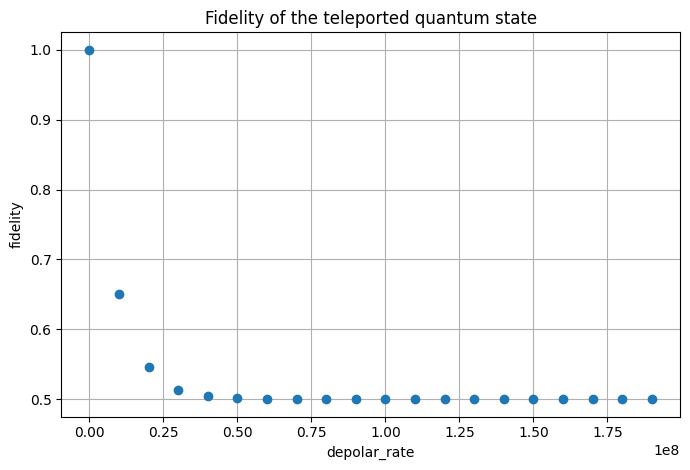

In [21]:
def create_plot(summary: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.errorbar(
        summary["depolar_rate"],
        summary["fidelity"],
        yerr=summary["sem"].fillna(0.0),
        fmt="o",
        capsize=3,
    )
    ax.set_title("Fidelity of the teleported quantum state")
    ax.set_xlabel("depolar_rate")
    ax.set_ylabel("fidelity")
    ax.grid(True)
    fig.tight_layout()
    return fig, ax


fig, ax = create_plot(summary)
fig.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
print(f"saved plot: {PLOT_PATH}")
plt.show()

In [22]:
assert len(fidelity_table) == NUM_RUNS * len(DEPOLAR_RATES)
assert summary.loc[summary["depolar_rate"] == 0.0, "fidelity"].iloc[0] > 1.0 - 1e-12
assert summary["fidelity"].between(0.0, 1.0 + 1e-12).all()
assert summary["samples"].eq(NUM_RUNS).all()

summary.tail()

,depolar_rate,fidelity,sem,samples
15,150000000.0,0.5,3.212886e-07,1000
16,160000000.0,0.5,1.968322e-07,1000
17,170000000.0,0.5,1.205853e-07,1000
18,180000000.0,0.5,7.387397e-08,1000
19,190000000.0,0.5,4.525721e-08,1000


## Notes

This version follows the BB84 architecture more closely:

- `Network("teleportation_three_node_network")` contains three nodes: `alice`, `bob`, and `charlie`.
- Alice owns `input_memory`, `entanglement_memory`, and `bsa` devices.
- Bob owns a `qmemory` device, and Charlie owns the `source` device.
- Alice, Bob, and Charlie each have a `NodeAgent` registered on the matching node.
- Alice emits both stored qubits into `BellStateAnalyzer`; the Bell result comes back as a `DetectionReport` through `AGENT_REPORT`.
- `SessionRuntime` binds devices/link transports, starts agents, and provides `ctx.memory`, `ctx.classical`, `ctx.devices`, and timers.
- Quantum/classical channels are declared as network links, and runtime event delivery is declared with `network.wire_ports(...)`.
- Fidelity is still collected from Bob's corrected memory state, not from an analytic replacement curve.
